# Phenotype clustering with bootstrapped likelihood test and other metrics
We have implemented bootstrapped optimization for class enumeration as a python class named `bootGridSearch`. But we acknoledge this process can be realy time consuming, and some unexpected things, lie energy shortages can jeopardize all the processing power and time dedicated. So we implemented a special recovery class named `rescue_bootGridSearch`. 

In [ ]:
import sys
import inspect
sys.path.append('./code')
from Adjbootstrap10 import rescue_bootGridSearch

# The dataset

The data used in this example comprise Dengue cases from Brazilian children 

- aged below 17 years old
- notified between 2017 and 2025
- notified within first 7 days from symptoms onset

- The data is alreay treated, and filtered for confirmed cases:
    - positivo: RESUL_PCR_==1 | RESUL_NS1==1 | RESUL_VI_N ==1 | IMUNOH_N==1  | HISTOPA_N ==1? além de SOROTIPO!=None
    - (DT_PCR - DT_SIN_PRI) ≤ 7 dias
    - (DT_NS1 - DT_SIN_PRI) ≤ 7 dias

we do not need to load the data again, neither specify the variable list. All is stored in the temporary files. 

We just need to specify the temporary folder

/mnt/Data/Projects/2507SINAN_py/code/Adjbootstrap10.py:767: FutureWarning: The provided callable <function mean at 0x79e780204fe0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  [pd.pivot_table(
/mnt/Data/Projects/2507SINAN_py/code/Adjbootstrap10.py:773: FutureWarning: The provided callable <function std at 0x79e780205120> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  pd.pivot_table(


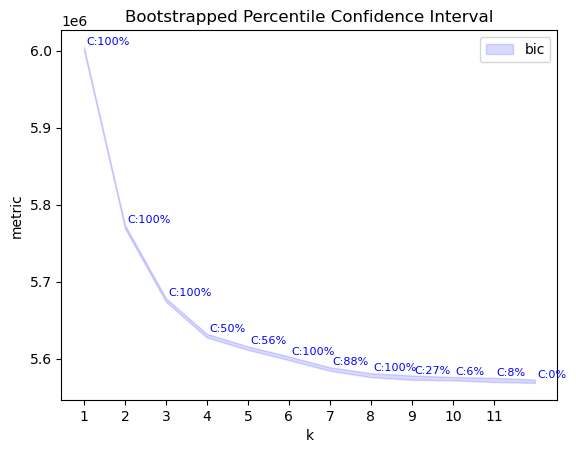

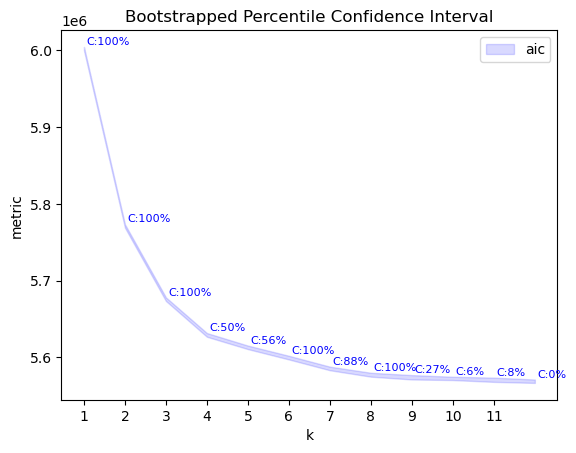

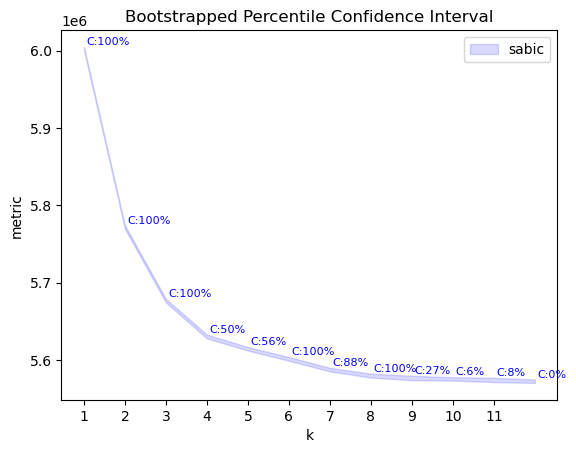

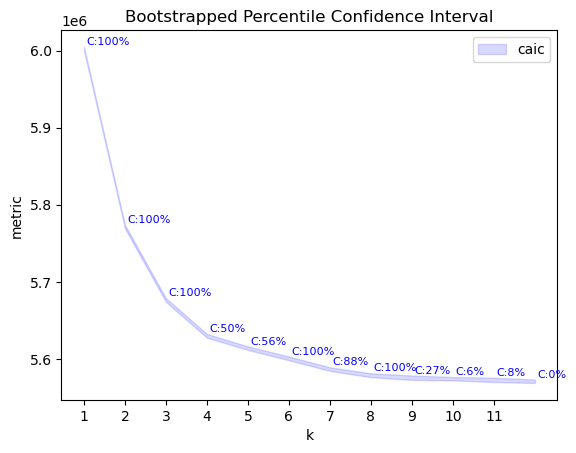

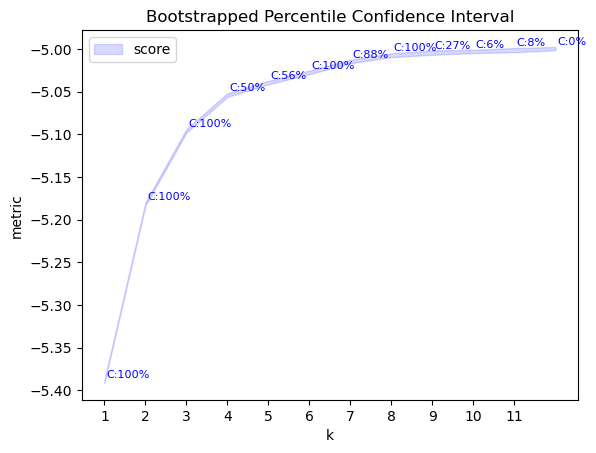

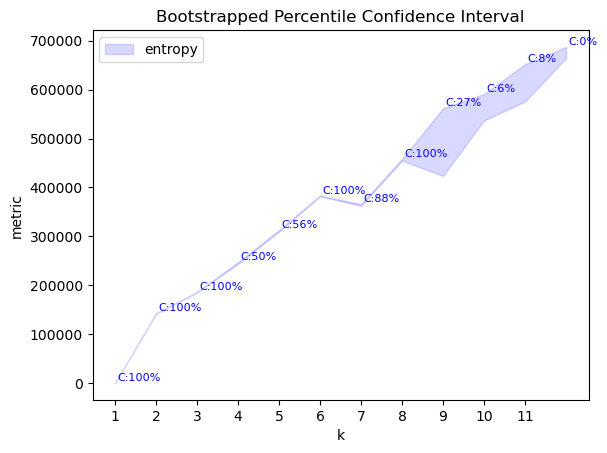

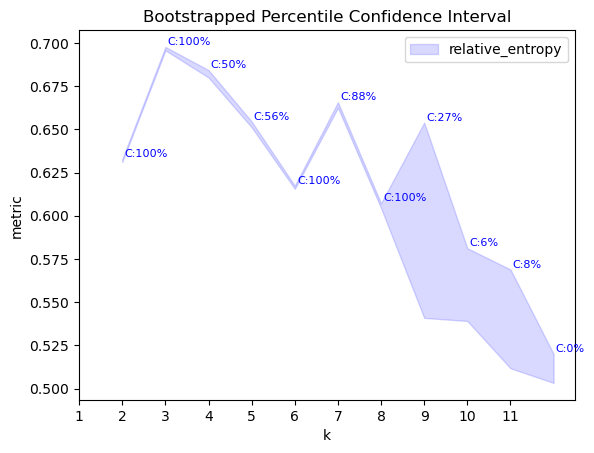

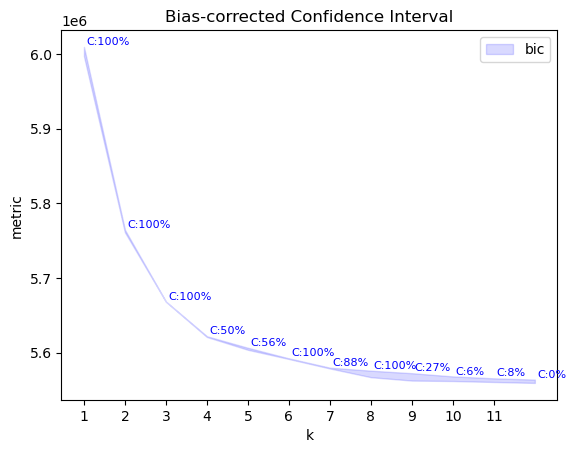

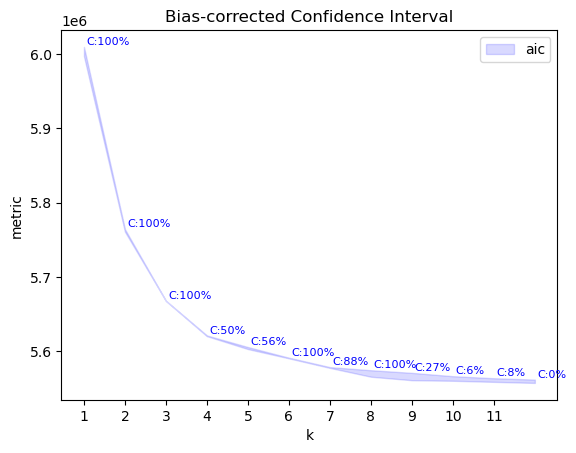

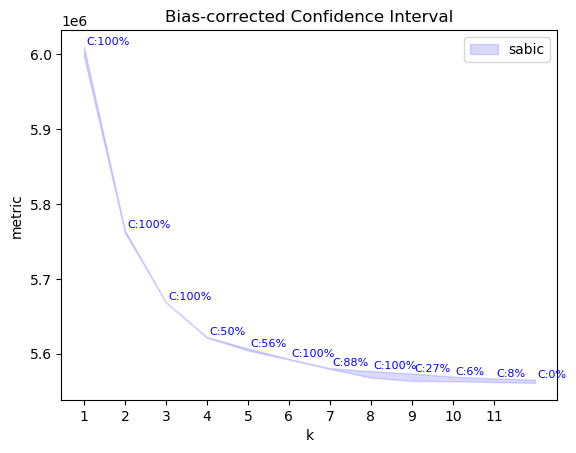

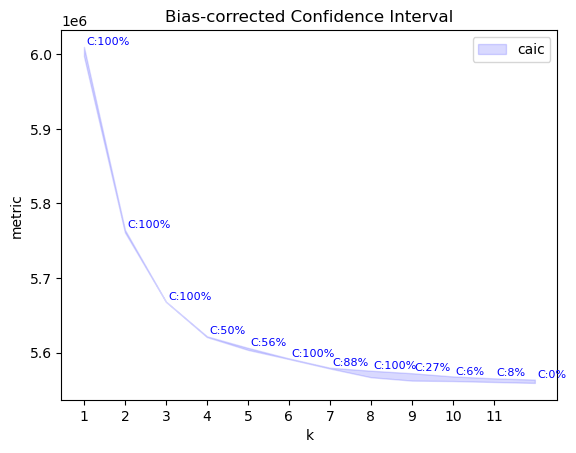

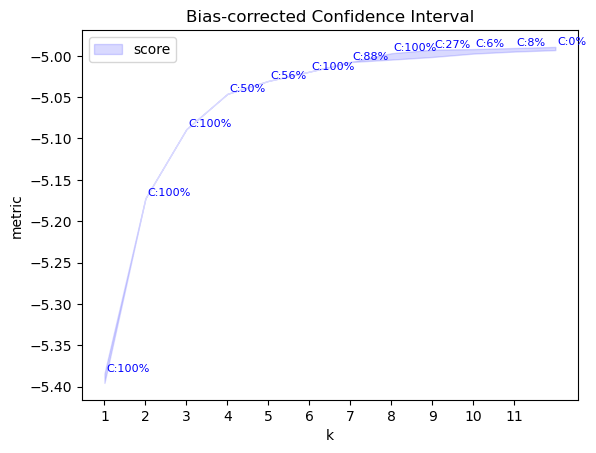

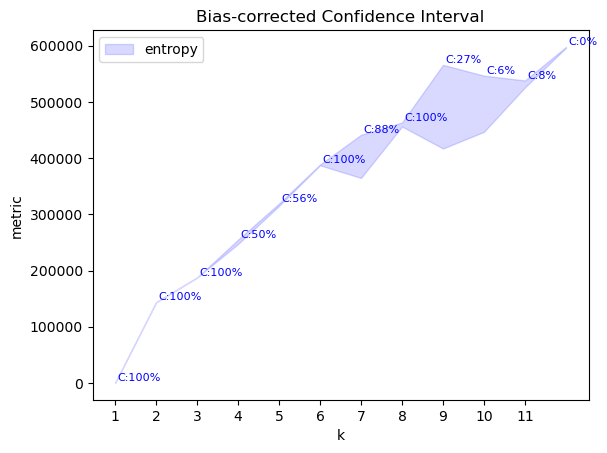

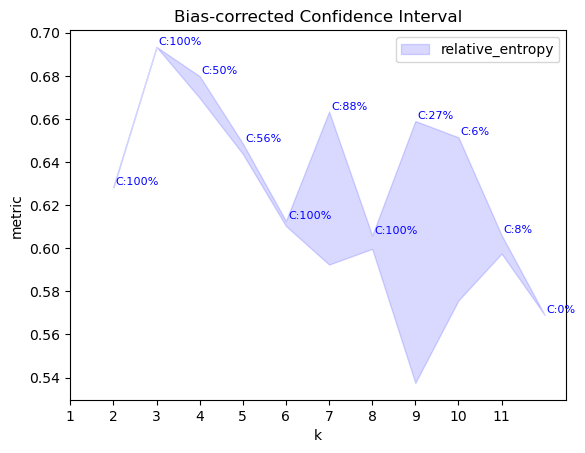

                       p
Test                    
-                    NaN
2 vs. 1 classes    0.000
3 vs. 2 classes    1.000
4 vs. 3 classes    0.200
5 vs. 4 classes    0.565
6 vs. 5 classes    0.775
7 vs. 6 classes    0.555
8 vs. 7 classes    0.765
9 vs. 8 classes    0.390
10 vs. 9 classes   0.375
11 vs. 10 classes  0.460
12 vs. 11 classes  0.485


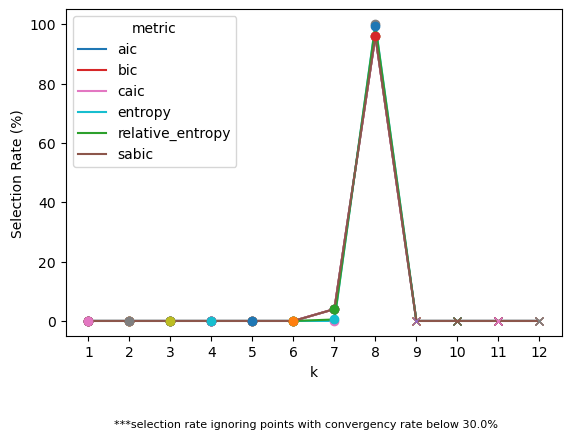

In [1]:

boot_res=rescue_bootGridSearch(path='./tempFile_2026-05-11_svspg1jr/temp_12.pkl')

In [2]:
min_k=boot_res.low
max_k=boot_res.high
import pickle
with open('./res/childGridS//bootstrap_lca_'+str(int(min_k))+'_'+str(int(max_k))+'.pkl', 'wb') as file:
    pickle.dump(boot_res, file)

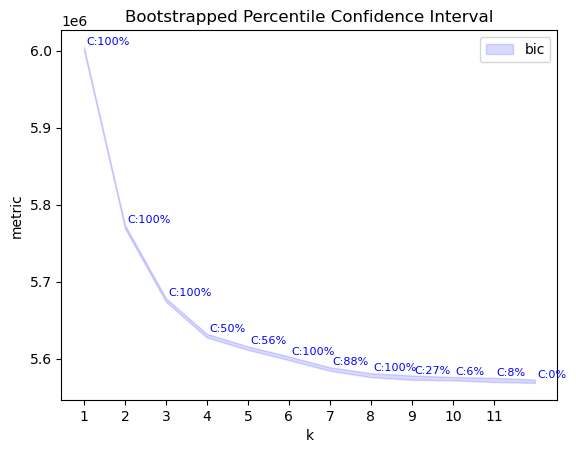

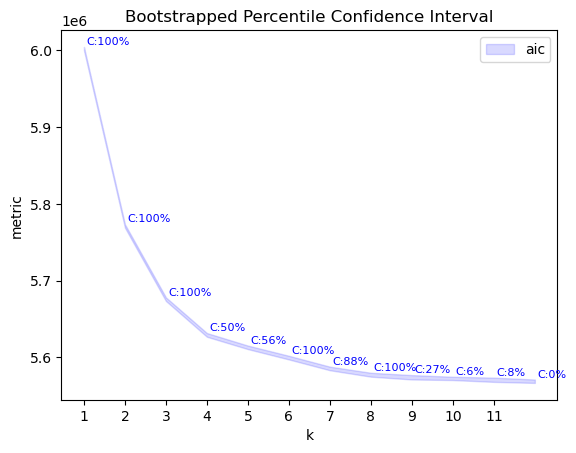

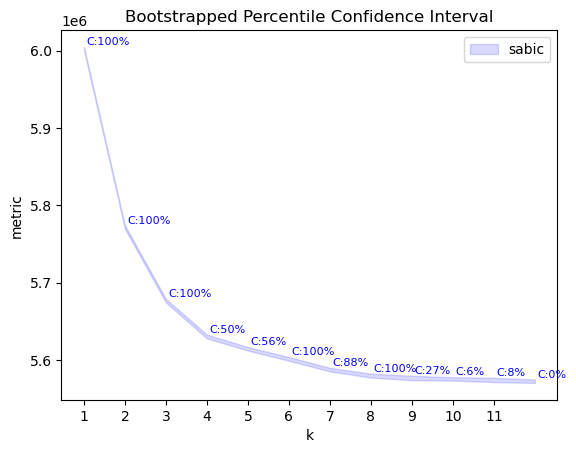

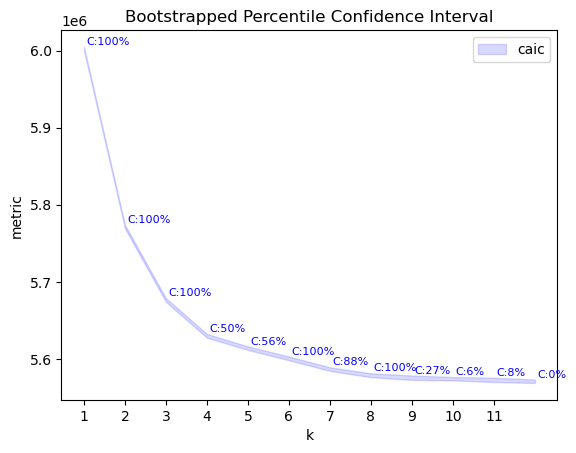

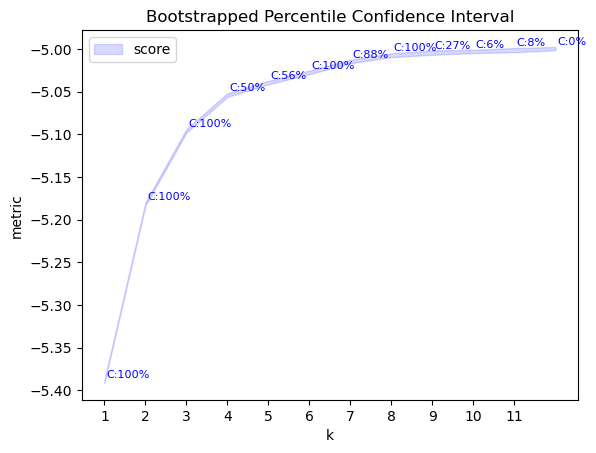

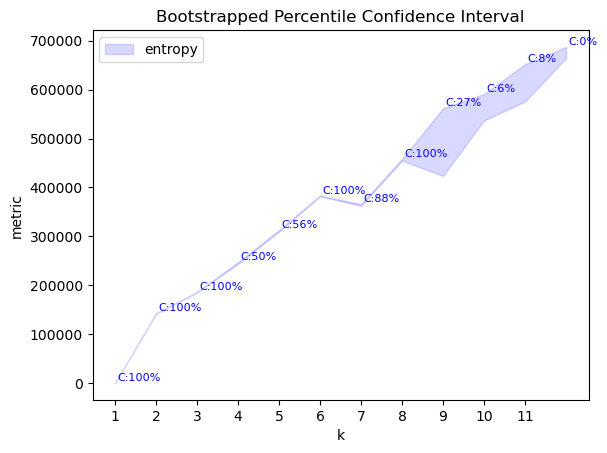

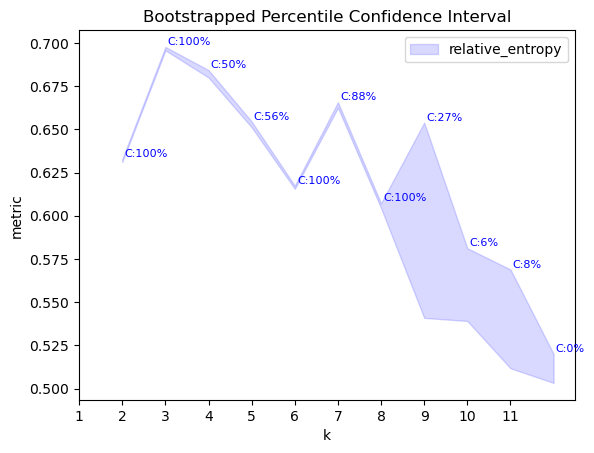

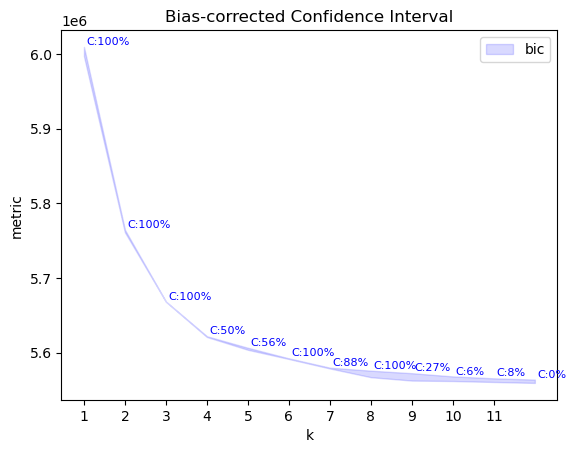

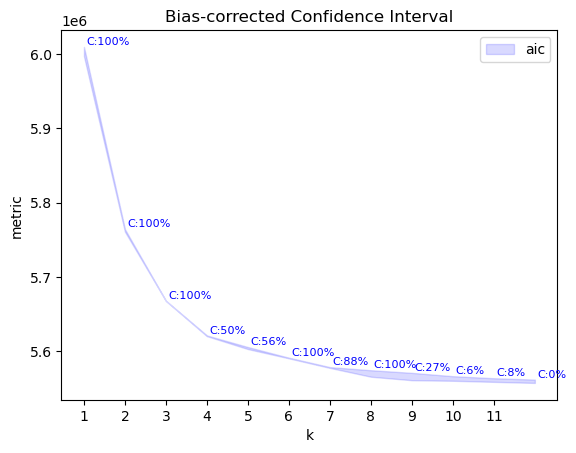

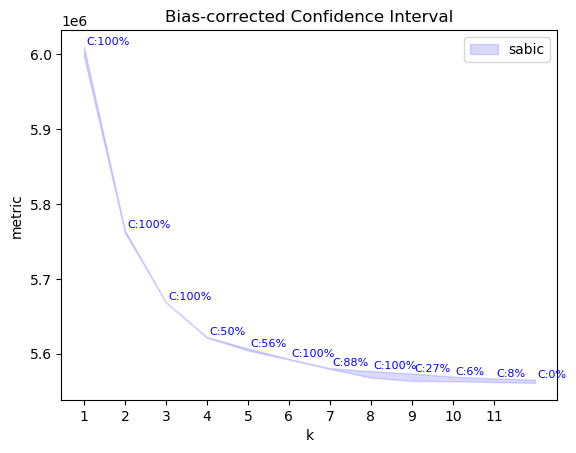

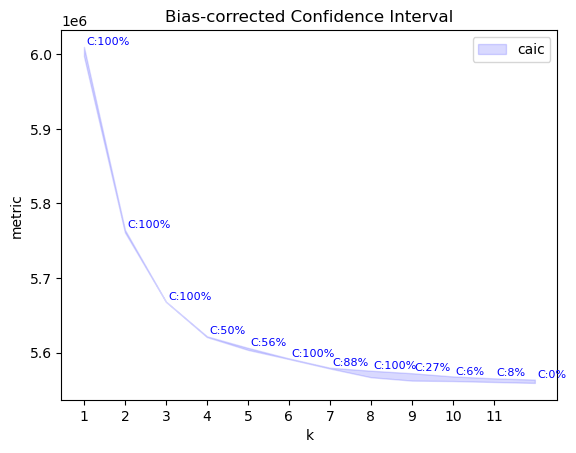

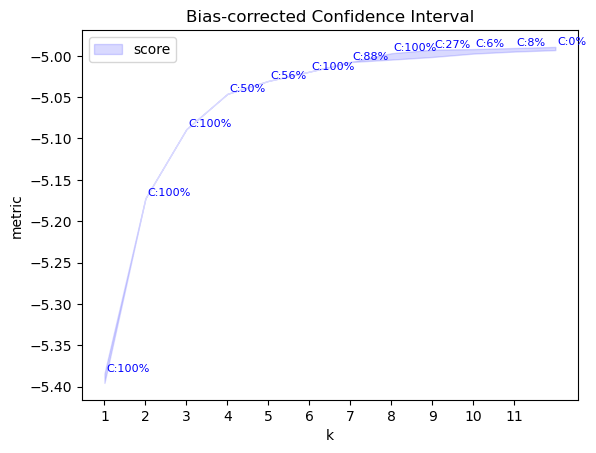

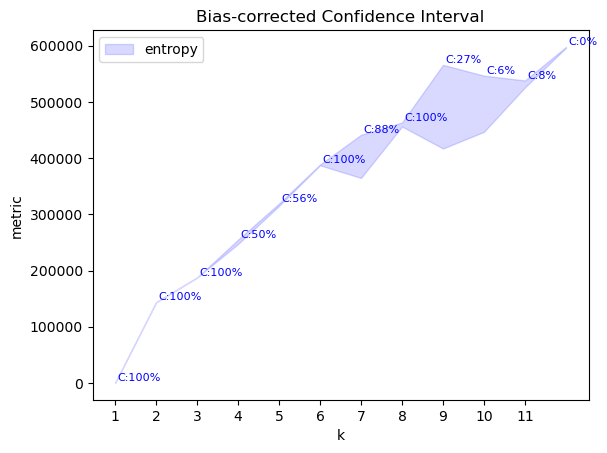

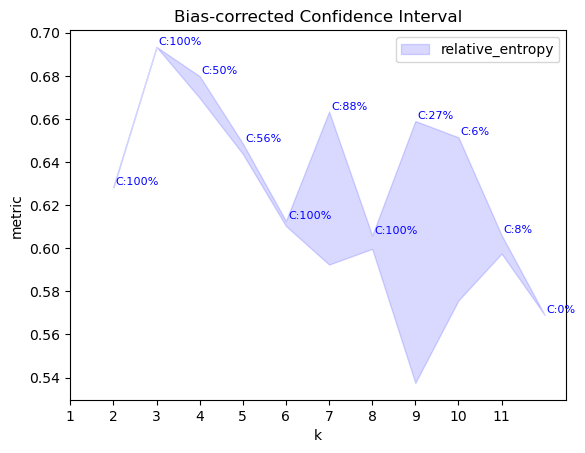

    blrt_p  k_                         CI_aic                         CI_bic  \
0      NaN   1  [5,997,104.596:6,009,569.174]  [5,997,261.818:6,009,726.396]   
1    0.000   2  [5,760,785.664:5,764,200.360]  [5,761,111.337:5,764,526.033]   
2    1.000   3  [5,667,623.765:5,667,793.052]  [5,668,117.890:5,668,287.177]   
3    0.200   4  [5,620,166.687:5,621,145.792]  [5,620,829.264:5,621,808.369]   
4    0.565   5  [5,602,785.104:5,605,496.779]  [5,603,616.132:5,606,327.808]   
5    0.775   6  [5,590,331.263:5,591,149.395]  [5,591,330.743:5,592,148.875]   
6    0.555   7  [5,577,440.806:5,578,480.544]  [5,578,608.737:5,579,648.476]   
7    0.765   8  [5,565,551.442:5,574,306.750]  [5,566,887.825:5,575,643.133]   
8    0.390   9  [5,560,869.054:5,570,760.670]  [5,562,373.889:5,572,265.505]   
9    0.375  10  [5,560,098.240:5,566,286.036]  [5,561,771.527:5,567,959.323]   
10   0.460  11  [5,558,644.611:5,563,531.396]  [5,560,486.349:5,565,373.135]   
11   0.485  12  [5,557,213.329:5,561,670

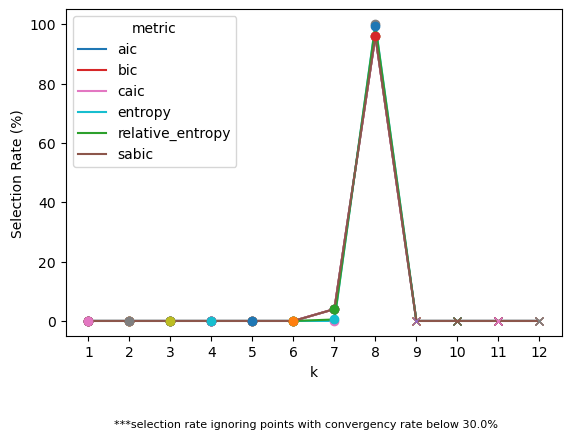

In [3]:
boot_res.report(path='./res/childGridS/bootstrap/')